### This notebook is designed as a structured guide through the fundamental steps of A/B Testing in Python.

__Scenario:__ 
The company "ShopFast" is testing a new and faster checkout page (Variation) against the current, traditional checkout page (Control).

__Goal:__ Increase the conversion rate (percentage of users who make a purchase).

__Duration:__ 21 Days

__Data:__
Generated later as 'ab_data.csv' (contains user_id, timestamp, group, landing_page, converted). 


### Step 1 
__Task A:__ Generate and load data.

__Task B:__ Import Libraries

__Goal:__ Prepare the environment.

In [2]:
# Task A

import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. Set parameters to match the common 294k-row dataset
n_rows = 294478
user_ids = np.arange(630000, 630000 + n_rows)
np.random.shuffle(user_ids)

# 2. Generate timestamps for a 22-day period
start_date = datetime(2023, 1, 1)
timestamps = [start_date + timedelta(seconds=np.random.randint(0, 1900800)) for _ in range(n_rows)]

# 3. Create groups and landing pages (50/50 split)
groups = np.random.choice(['control', 'treatment'], size=n_rows)
# Mapping group to expected landing page
landing_pages = ['old_page' if g == 'control' else 'new_page' for g in groups]

# 4. Generate conversion results based on specific probabilities
# Baseline (Control) = 13%, Treatment = 15% (to simulate a successful test)
converted = []
for g in groups:
    if g == 'control':
        converted.append(np.random.choice([0, 1], p=[0.87, 0.13]))
    else:
        converted.append(np.random.choice([0, 1], p=[0.85, 0.15]))

# 5. Build and save the DataFrame
df = pd.DataFrame({
    'user_id': user_ids,
    'timestamp': [t.strftime('%Y-%m-%d %H:%M:%S.%f') for t in timestamps],
    'group': groups,
    'landing_page': landing_pages,
    'converted': converted
})

df.to_csv('ab_data.csv', index=False)
print("File 'ab_data.csv' successfully generated!")

File 'ab_data.csv' successfully generated!


In [3]:
# Task B

import statsmodels.stats.api as sms
from scipy.stats import norm
import matplotlib.pyplot as plt

# Load the dataset 
df = pd.read_csv('ab_data.csv')

# Display first few rows and data info
print(df.head())
print(df.info())

   user_id                   timestamp      group landing_page  converted
0   789359  2023-01-04 17:41:22.000000    control     old_page          0
1   690930  2023-01-04 02:48:45.000000    control     old_page          1
2   851473  2023-01-10 03:10:54.000000  treatment     new_page          0
3   706295  2023-01-03 13:55:53.000000    control     old_page          0
4   820232  2023-01-08 13:38:16.000000    control     old_page          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB
None


### Step 2 
__Task:__ Identify the independent and dependent variables. Define the Null (Ho) and Alternative (Ha) Hypotheses.

__Goal:__ Formulate a measurable, actionable goal.

### Answer Here
__Independent Variable:__ 

__Dependent Variable:__ 

__Null Hypothesis(Ho):__ 
Hint: P_new <= P_old

__Alternative Hypothesis(Ha):__ 
Hint: P_new > P_old

### Step 3 
__Task:__ Check for data quality issues.

__1:__ Ensure users in the 'control' group only saw the 'old_page'.

__2:__ Ensure users in the 'treatment' group only saw the 'new_page'.

__3:__ Remove any mismatched rows.

__4:__ Check for duplicate users.

In [4]:
# Check for mismatch users by group. Be mindful of the next step in the logic.
mismatches = df[((df['group'] == 'treatment') == (df['landing_page'] == 'old_page'))]
print(f"Mismatched rows: {len(mismatches)}")

# Remove mismatches
df_clean = df.drop(mismatches.index)

# Verify no users were in both groups using the .duplicated() method
duplicate_users = df_clean['user_id'].duplicated().sum()
print(f"Duplicate users: {duplicate_users}")

Mismatched rows: 0
Duplicate users: 0


### Step 4 
__Task:__ Calculate the required sample size to detect a 2% improvement (Minimum Detectable Effect) with 95% confidence and 80% power.

__Note__ Minimum Detectable Effect(MDE) is the smallest, pratically meaningful change in a metric that an A/B test can reliably detect with a given power. MDE determines experiment sensitvity.

__Goal:__ Ensure the test is statistically robust. 

In [5]:
# Parameters
baseline_rate = df_clean[df_clean['group'] == 'control']['converted'].mean()
mde = 0.02  # 2% improvement
power = 0.8
alpha = 0.05

# Calculate required sample size
effect_size = sms.proportion_effectsize(baseline_rate, baseline_rate + mde)
required_n = sms.NormalIndPower().solve_power(effect_size, power=power, alpha=alpha, ratio=1)
print(f"Required sample size per group: {round(required_n)}")
print(f"Current sample size in data: {len(df_clean)/2}")

Required sample size per group: 4724
Current sample size in data: 147239.0


### Step 5 
__Task:__ Calculate conversion rates, visualize, and perform a Z-test for proportions to determine statistical significance.
__Goal:__ Reject or fail to reject the null hypothesis. 

In [6]:
# Summary statistics
summary = df_clean.groupby('group')['converted'].agg(['count', 'sum', 'mean'])
summary.columns = ['Total Users', 'Converted', 'Conversion Rate']
print(summary)

# Z-test
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

control_results = df_clean[df_clean['group'] == 'control']['converted']
treat_results = df_clean[df_clean['group'] == 'treatment']['converted']

n_con = control_results.count()
n_treat = treat_results.count()
successes = [control_results.sum(), treat_results.sum()]
nobs = [n_con, n_treat]

z_stat, pval = proportions_ztest(successes, nobs=nobs)
(lower_con, lower_treat), (upper_con, upper_treat) = proportion_confint(successes, nobs=nobs, alpha=0.05)

print(f'z-statistic: {z_stat:.4f}')
print(f'p-value: {pval:.4f}')
print(f'Confidence Interval 95% (Control): [{lower_con:.4f}, {upper_con:.4f}]')
print(f'Confidence Interval 95% (Treatment): [{lower_treat:.4f}, {upper_treat:.4f}]')

           Total Users  Converted  Conversion Rate
group                                             
control         147765      19232         0.130153
treatment       146713      22050         0.150293
z-statistic: -15.7404
p-value: 0.0000
Confidence Interval 95% (Control): [0.1284, 0.1319]
Confidence Interval 95% (Treatment): [0.1485, 0.1521]


### Step 6 
__Task:__ Based on the p-value (<0.05) and the confidence interval, does the new page perform better?

__Action:__ Recommend whether to launch the new page, keep the old one, or continue testing.

### Answer Here



### Step 7 
__Task:__ Visualize this performance comparison using seaborn.

__Action:__ Determine if ShopFast should reject or accept the null hypothesis (Ho).

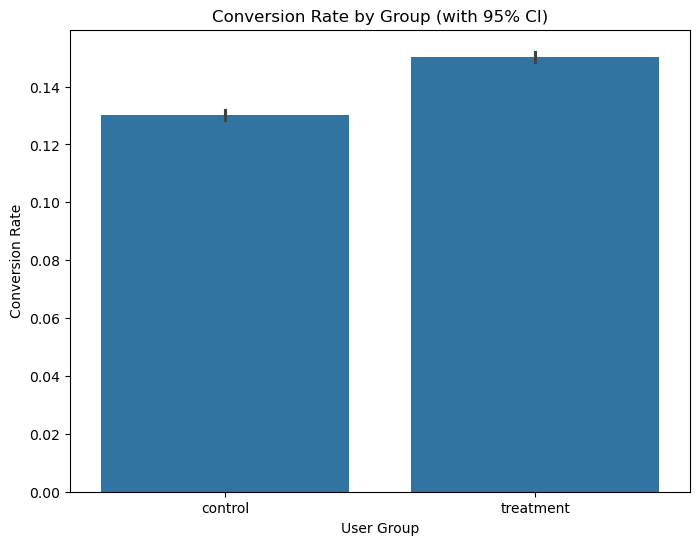

In [7]:
import seaborn as sns

# Visualizing the conversion rates
plt.figure(figsize=(8, 6))
sns.barplot(x='group', y='converted', data=df_clean, errorbar=('ci',95))

plt.title('Conversion Rate by Group (with 95% CI)')
plt.ylabel('Conversion Rate')
plt.xlabel('User Group')
plt.show()

### Answer Here